# Clasificación de perros y gatos

Tutorial: https://www.geeksforgeeks.org/machine-learning/image-classification-using-support-vector-machine-svm-in-python/

Dataset completo: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

Dataset reducido a 500 imágenes solamente: https://github.com/rubenchov/aprendizajeautomaticovision/releases/download/v1.0.0/Dataset500.zip

Importar librerías

In [1]:
import pandas as pd
import os
import cv2

from skimage.transform import resize
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import hog

import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


#Google Drive
from google.colab import drive
drive.mount('/content/drive')
datadir = '/content/drive/MyDrive/2026/2026-1/Docencia/Visión con IA/2. Aprendizaje Automático/Cats&Dogs/Dataset500' #Actualizar ruta dependiendo de dónde tenga su conjunto de datos completo o reducido


Mounted at /content/drive


#Cargar conjunto de datos

En el siguiente bloque de código se lee cada una de las imágenes en la

In [2]:
Categories=['Cat','Dog']
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in os.listdir(path): #Se leen todas las imágenes que estén en la ruta definida por "path"
      img_array=imread(os.path.join(path, img))
      img_resized=resize(img_array, (150, 150, 3))
      if img_resized.flatten().shape == (67500, ): #Se aplana la imagen, por lo tanto tendrá 67500 columnas, es decir, la misma cantidad de características.
        flat_data_arr.append(img_resized.flatten()) #Se añade cada muestra a la lista.
        target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat
loaded category: Cat successfully
loading... category: Dog
loaded category: Dog successfully


In [3]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

Crear dataframe de Pandas

In [4]:
#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(999, 67501)


#Modelo

Se define un modelo de clasificación con Máquina de Soporte vectorial (SVC). La ejecución será un poco demorada, dado el número de características que se definieron para el conjunto de datos.

*Ejercicio recomendado: probar otros modelos vistos*

In [5]:
# Creating a support vector classifier
model = svm.SVC()

param_grid = {'kernel': ['rbf', 'linear', 'poly']}
grid = GridSearchCV(model, param_grid, cv=2, verbose=2, n_jobs=-1) #Se está haciendo una búsqueda en malla (grid search) definiendo 3 tipos de kernel, y se elige automáticamente el mejor.

# Training the model using the training data
grid.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'kernel': ['rbf', 'linear', 'poly']}, verbose=2)

In [6]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid.best_score_:.2f}")

Mejores parámetros encontrados: {'kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.60


#Predecir

In [7]:
# Testing the model using the testing data
y_pred = grid.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy = accuracy_score(y_pred, y_test)

# Print the accuracy of the model
print(f"The model is {accuracy * 100}% accurate")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

The model is 57.99999999999999% accurate
              precision    recall  f1-score   support

         cat       0.59      0.53      0.56       100
         dog       0.57      0.63      0.60       100

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200



Se analiza de los anteriores resultados, que la posibilidad de adivinar usando una moneda al azar, es del 50%, mientras que el resultado de este modelo fue del 60%, lo cual no es un buen resultado.

Seleccionar muestra aleatoria del subconjunto de validación y mostrar resultados.

El siguiente bloque de código se debe correr varias veces para generar nuevas muestras aleatorias, una por cada vez que se corra.

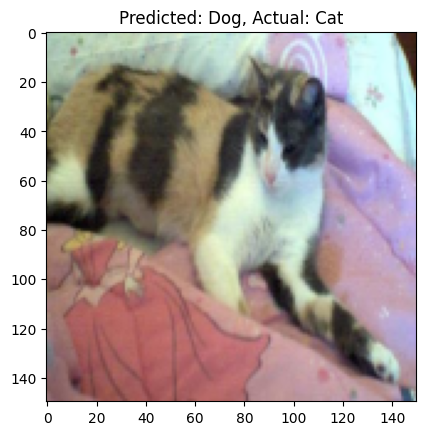

In [8]:
rand_index = np.random.randint(0, len(y_test))
rand_img = x_test.iloc[rand_index].values.reshape(150, 150, 3)
rand_class = y_test.iloc[rand_index]
pred_class = y_pred[rand_index]

plt.imshow(rand_img)
plt.title(f"Predicted: {Categories[pred_class]}, Actual: {Categories[rand_class]}")
plt.show()

#Redefinición del conjunto de datos

Como se vio anteriormente, tomar la imagen completa y aplanarla hasta 67500 características, no fue la mejor opción. Esto se explica porque los pixeles individuales en sus respectivas posiciones no aportan mucho para la clasificación entre perros y gatos. Sería más adecuado usar su textura, atributos de color u otras características para determinar la diferencia entre estos 2 tipos de clases.



Se usa HOG (Histogram of Oriented Gradients) lo cual funciona de la siguiente manera:

Calcula los gradientes: Detecta los bordes de la imagen midiendo dónde y con qué intensidad cambia el brillo de los píxeles.

Mide las direcciones: Identifica la orientación (los ángulos) de esos bordes en cada zona.

Agrupa por celdas: Divide la imagen en pequeñas cuadrículas y cuenta cuántos bordes apuntan hacia cada dirección en esa región.

Normaliza la iluminación: Agrupa las celdas en bloques más grandes para corregir las sombras y los cambios de luz globales.

Crea la firma visual: Une toda esa información en un único vector numérico que representa la silueta y las formas de la imagen.

In [12]:
def extraer_hog_global(imagen_path):
    # 1. Cargar imagen y convertir a escala de grises
    img_bgr = cv2.imread(imagen_path)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Opcional: Redimensionar para asegurar un tamaño fijo en todo el dataset
    img_gris = cv2.resize(img_gris, (128, 128))

    # 3. Extraer características HOG de toda la imagen de una sola vez
    caracteristicas_hog = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    return caracteristicas_hog

In [13]:
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in os.listdir(path): #Se leen todas las imágenes que estén en la ruta definida por "path"
      hog_features = extraer_hog_global(os.path.join(path, img))
      flat_data_arr.append(hog_features) #Se añade cada muestra a la lista.
      target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat
loaded category: Cat successfully
loading... category: Dog
loaded category: Dog successfully


In [14]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

In [15]:
#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(1000, 8101)


Como se evidencia, el análisis con HOG entregó 8100 características, dado que:

Celdas en la imagen: La imagen es de 128x128 y se divide en celdas de 8x8, por lo tanto se generan 16x16 celdas.

Bloques deslizantes: Los bloques son de 2x2 celdas y se deslizan de una en una. En una cuadrícula de 16x16, caben exactamente 15x15 = 225 bloques.

Valores por bloque: Cada bloque tiene 4 celdas de 2x2, y cada celda tiene 9 orientaciones (canales). Eso da 4x9 = 36 valores por bloque.

Total del vector: 225 bloques x 36 valores = 8100 características.



In [17]:
# Creating a support vector classifier
model = svm.SVC()

param_grid = {'kernel': ['rbf', 'linear', 'poly']}
grid = GridSearchCV(model, param_grid, cv=2, verbose=2, n_jobs=-1) #Se está haciendo una búsqueda en malla (grid search) definiendo 3 tipos de kernel, y se elige automáticamente el mejor.

# Training the model using the training data
grid.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'kernel': ['rbf', 'linear', 'poly']}, verbose=2)

In [18]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid.best_score_:.2f}")

Mejores parámetros encontrados: {'kernel': 'poly'}
Mejor precisión en validación cruzada: 0.73


Este resultado del 73% ya es una mejora significativa respecto al 50% del azar que se puede obtener, 60% que se obtuvo con la SVC sobre todos los pixeles de la imagen. En este caso se extrajeron 8100 características de cada imagen y con esto se incrementó un 13% la precisión del clasificador.

*Ejercicio propuesto: consultar otros descriptores de textura y bordes que permitan incrementar la precisión del clasificador.*